<h1>Today we will be starting to write Regression Model from scratch </h1>

importing kaggle datasets

In [202]:
!pip install kagglehub

In [203]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andonians/random-linear-regression")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Lenovo\.cache\kagglehub\datasets\andonians\random-linear-regression\versions\2


Importing major libraries and modules

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [205]:
path="C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\andonians\\random-linear-regression\\versions\\2"
train_data = pd.read_csv(path + "\\train.csv")
test_data = pd.read_csv(path + "\\test.csv")

In [206]:
train_data.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [207]:
train_data.describe()

,x,y
count,700.000000,699.000000
mean,54.985939,49.939869
std,134.681703,29.109217
min,0.000000,-3.839981
25%,25.000000,24.929968
50%,49.000000,48.973020
75%,75.000000,74.929911
max,3530.157369,108.871618


In [208]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [209]:
train_data.isnull().sum()

x    0
y    1
dtype: int64

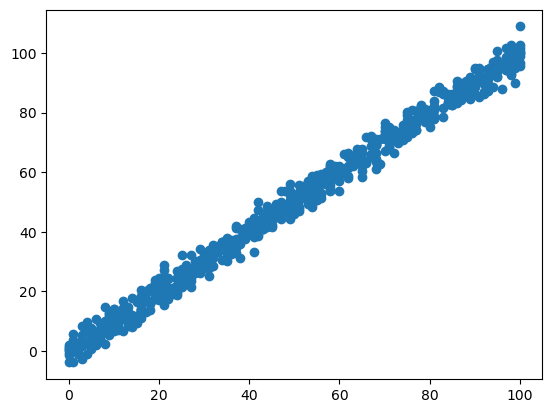

In [210]:
plt.scatter(train_data['x'], train_data['y'])

In [211]:
train_data.dropna(inplace=True)

In [212]:
import numpy as np

def Loss_Function(m, c, x, y):
    n = len(x)
    y_pred = m * x + c
    error = y - y_pred
    return np.mean(error ** 2)   # average loss

def Gradient_Descent(m, c, x, y, learning_rate):
    n = len(x)
    y_pred = m * x + c
    error = y - y_pred
    m_grad = -(2/n) * np.dot(x, error)
    c_grad = -(2/n) * np.sum(error)

    # gradient clipping
    m_grad = np.clip(m_grad, -1e6, 1e6)
    c_grad = np.clip(c_grad, -1e6, 1e6)

    m -= learning_rate * m_grad
    c -= learning_rate * c_grad
    return m, c

# Normalize data
x = train_data['x'] / np.max(train_data['x'])
y = train_data['y'] / np.max(train_data['y'])

m, c = 0.0, 0.0
learning_rate = 0.1
for i in range(1000):
    loss = Loss_Function(m, c, x, y)
    if np.isnan(loss):
        print(f"NaN detected at iteration {i+1}, stopping.")
        break
    print(f"Iteration {i+1}: Loss={loss}, m={m}, c={c}")
    m, c = Gradient_Descent(m, c, x, y, learning_rate)


Iteration 1: Loss=0.28179503734772765, m=0.0, c=0.0
Iteration 2: Loss=0.17538049292740956, m=0.06127261882573737, c=0.0917408410938589
Iteration 3: Loss=0.11561571441850595, m=0.10927723577549828, c=0.15900449893561902
Iteration 4: Loss=0.08185496522392656, m=0.14734820001286686, c=0.20801358999139152
Iteration 5: Loss=0.06259485235473823, m=0.17797477998264052, c=0.24341267711429737
Iteration 6: Loss=0.05142577843094383, m=0.2030154416197807, c=0.2686684125186498
Iteration 7: Loss=0.04477623523824014, m=0.2238577930359487, c=0.28636821820741243
Iteration 8: Loss=0.0406560045154881, m=0.24153797279715827, c=0.2984432312691257
Iteration 9: Loss=0.03795591414812434, m=0.25682976550346404, c=0.3063347178717098
Iteration 10: Loss=0.036057687143714205, m=0.2703111207858646, c=0.31111829034973576
Iteration 11: Loss=0.03461656322602004, m=0.28241380543654526, c=0.3135966270712903
Iteration 12: Loss=0.03344018316116609, m=0.2934604655294532, c=0.3143686816977821
Iteration 13: Loss=0.0324211072

In [213]:
print("Slope (m):", m)
print("Intercept (c):", c)

Slope (m): 0.9191147216393747
Intercept (c): -0.0009846027369688024


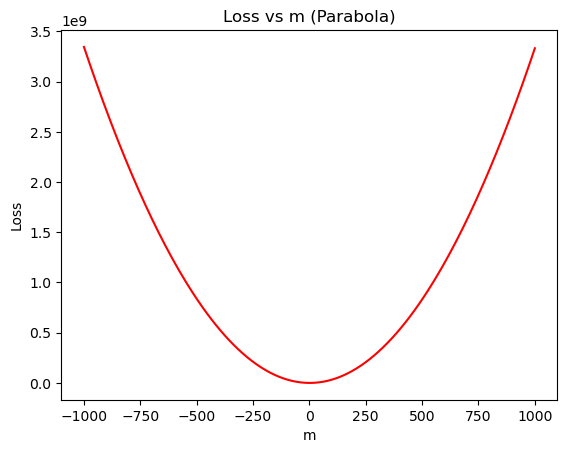

Minimum Loss = 54124.1710 at m = 5.0251


In [214]:
import numpy as np
import matplotlib.pyplot as plt

def plot_loss_curve(x, y):
    m_values = np.linspace(-1000, 1000, 200)
    losses = []
    for m in m_values:
        y_pred = m * x  # assume c=0 for simplicity
        loss = np.mean((y - y_pred) ** 2)   # scalar loss
        losses.append(loss)

    plt.plot(m_values, losses, color='red')
    plt.xlabel('m')
    plt.ylabel('Loss')
    plt.title('Loss vs m (Parabola)')
    plt.show()

    # minimum loss and corresponding m
    min_loss = min(losses)
    best_m = m_values[np.argmin(losses)]
    print(f"Minimum Loss = {min_loss:.4f} at m = {best_m:.4f}")

plot_loss_curve(train_data['x'], train_data['y'])


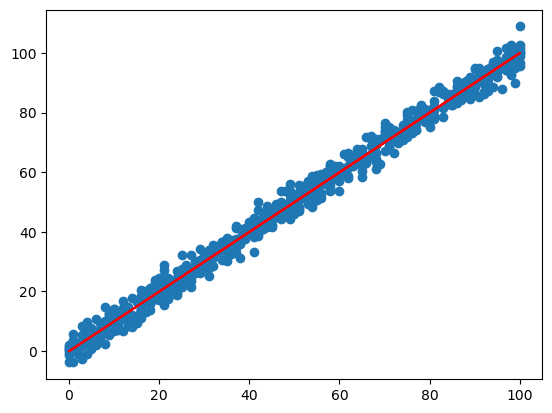

In [215]:
plt.scatter(train_data['x'], train_data['y'])
y_pred = m * x + c
plt.plot(train_data['x'], y_pred * np.max(train_data['y']), color='red')  # scale back to original y
plt.show()